# Stage 02 - End-to-End Training Baseline Model
Notebook này thực hiện huấn luyện từ đầu đến cuối mô hình CNN Baseline cho bài toán Face Anti-Spoofing.
Có bao gồm việc đánh giá ACER (HTER), APCER, BPCER, F1-Score, AUC và tìm ngưỡng EER tốt nhất.

In [1]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torchinfo import summary

# Thêm thư mục gốc vào sys.path để import utils và models
sys.path.append('..')
from utils.config import Config
from utils.data import get_dataloaders
from utils.train import fit
from utils.evaluate import plot_training_history, evaluate_test_set, plot_misclassified_samples
from models.baseline_model import BaselineModelCNN

# Khởi tạo config
config = Config()
device = config.DEVICE
print(f"Using device: {device}")

Using device: xpu


In [2]:
# Khởi tạo dataloaders
train_loader, val_loader, test_loader, class_names = get_dataloaders()

print(f"Các nhãn: {class_names}")
print(f"Số batch tập train: {len(train_loader)}")
print(f"Số batch tập val: {len(val_loader)}")
print(f"Số batch tập test: {len(test_loader)}")

[*] Đang nạp dataset 'train' vào Shared RAM...


Cache train:   0%|          | 0/8299 [00:00<?, ?it/s]

[*] Nạp thành công 8299 ảnh (1191.4 MB)
[*] Đang nạp dataset 'val' vào Shared RAM...


[*] Nạp thành công 2948 ảnh (423.2 MB)
[*] Tập test nạp trực tiếp từ ổ cứng (không dùng Cache RAM).
Các nhãn: ['real', 'spoof']
Số batch tập train: 259
Số batch tập val: 93
Số batch tập test: 237


In [3]:
# Khởi tạo mô hình, loss, optimizer
print(f"Đang sử dụng thiết bị: {device}")

model = BaselineModelCNN(num_classes=2).to(device)

print(f"Tổng tham số : {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
print(summary(model, (1, 3, config.IMG_SIZE, config.IMG_SIZE), device=device))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Đang sử dụng thiết bị: xpu
Tổng tham số : 430562
Layer (type:depth-idx)                   Output Shape              Param #
BaselineModelCNN                         [1, 2]                    --
├─Sequential: 1-1                        [1, 256, 14, 14]          --
│    └─Conv2d: 2-1                       [1, 32, 224, 224]         864
│    └─BatchNorm2d: 2-2                  [1, 32, 224, 224]         64
│    └─ReLU: 2-3                         [1, 32, 224, 224]         --
│    └─MaxPool2d: 2-4                    [1, 32, 112, 112]         --
│    └─Conv2d: 2-5                       [1, 64, 112, 112]         18,432
│    └─BatchNorm2d: 2-6                  [1, 64, 112, 112]         128
│    └─ReLU: 2-7                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-8                    [1, 64, 56, 56]           --
│    └─Conv2d: 2-9                       [1, 128, 56, 56]          73,728
│    └─BatchNorm2d: 2-10                 [1, 128, 56, 56]          256
│    └─ReLU: 2-11        

In [4]:
# Vòng lặp huấn luyện (Training Loop) với hàm tiện ích
epochs = 20

# Gọi hàm fit từ utils/train.py
model, history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    class_names=class_names,
    epochs=epochs,
    config=config,
    scheduler=None,
    experiment_name="baseline"
)

[*] Đang sử dụng utils.train đã được cập nhật API autocast!
[*] Đã bật chế độ bộ nhớ Channels-Last.
[*] Đã bật Automatic Mixed Precision (AMP) với bfloat16.


Epoch 01/20 | Train Loss/Acc: 0.5384/0.7360 | Val Loss/Acc: 0.6802/0.6255 | APCER/BPCER/ACER: 0.4219/0.0765/0.2492 | Threshold: 0.3086 ⭐ [BEST]


Epoch 02/20 | Train Loss/Acc: 0.4476/0.7972 | Val Loss/Acc: 0.6770/0.6116 | APCER/BPCER/ACER: 0.4373/0.0815/0.2594 | Threshold: 0.2969


Epoch 03/20 | Train Loss/Acc: 0.3727/0.8480 | Val Loss/Acc: 0.6599/0.6988 | APCER/BPCER/ACER: 0.3405/0.0543/0.1974 | Threshold: 0.2754 ⭐ [BEST]


Epoch 04/20 | Train Loss/Acc: 0.3227/0.8640 | Val Loss/Acc: 0.3161/0.8701 | APCER/BPCER/ACER: 0.0350/0.7259/0.3805 | Threshold: 0.9141


...

Epoch 16/20 | Train Loss/Acc: 0.1390/0.9439 | Val Loss/Acc: 0.2572/0.9081 | APCER/BPCER/ACER: 0.0531/0.3358/0.1944 | Threshold: 0.8906


Epoch 17/20 | Train Loss/Acc: 0.1193/0.9562 | Val Loss/Acc: 0.2659/0.8945 | APCER/BPCER/ACER: 0.0959/0.1654/0.1307 | Threshold: 0.6523 ⭐ [BEST]


Epoch 18/20 | Train Loss/Acc: 0.1248/0.9525 | Val Loss/Acc: 0.6732/0.7592 | APCER/BPCER/ACER: 0.2650/0.0889/0.1770 | Threshold: 0.1660


Epoch 19/20 | Train Loss/Acc: 0.1162/0.9568 | Val Loss/Acc: 0.5172/0.8022 | APCER/BPCER/ACER: 0.2139/0.0963/0.1551 | Threshold: 0.1855


Epoch 20/20 | Train Loss/Acc: 0.1053/0.9607 | Val Loss/Acc: 0.3768/0.8436 | APCER/BPCER/ACER: 0.1648/0.1037/0.1342 | Threshold: 0.3770

[+] Quá trình huấn luyện hoàn tất!
[*] Đang tải lại trọng số của mô hình tốt nhất (Best Model) để đánh giá...


## Đánh giá và Phân tích kết quả

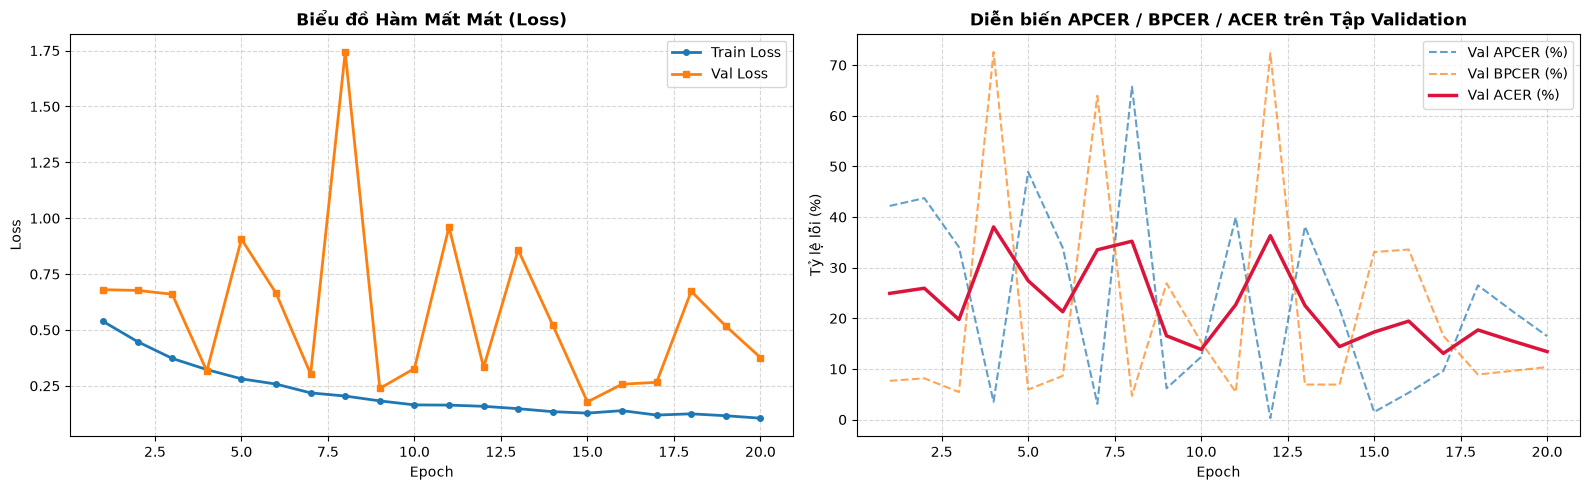

[*] Thu thập kết quả dự đoán trên tập Val...


[*] Thu thập kết quả dự đoán trên tập Test...


✅ Đánh giá xong! F1-Score trên tập Test: 0.9566 (Threshold = 0.6523)

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        real       0.32      0.85      0.47       314
       spoof       0.99      0.92      0.96      7266

    accuracy                           0.92      7580
   macro avg       0.66      0.88      0.71      7580
weighted avg       0.97      0.92      0.94      7580

-----------------------------



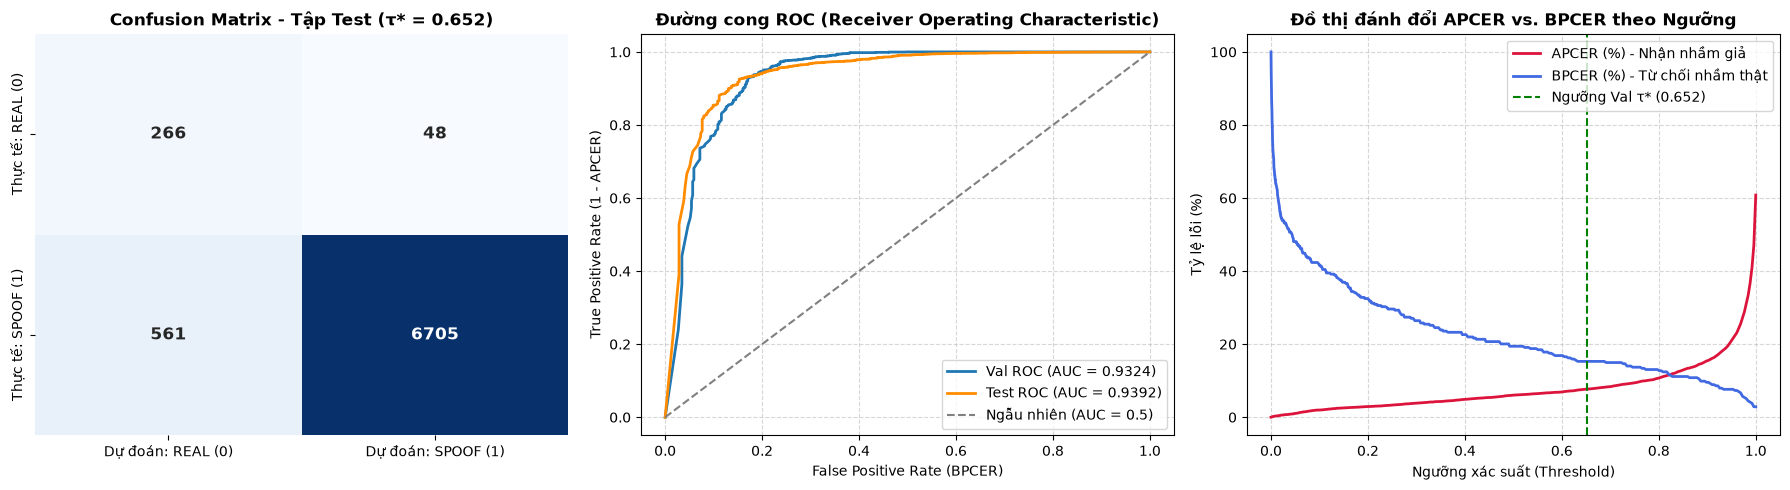

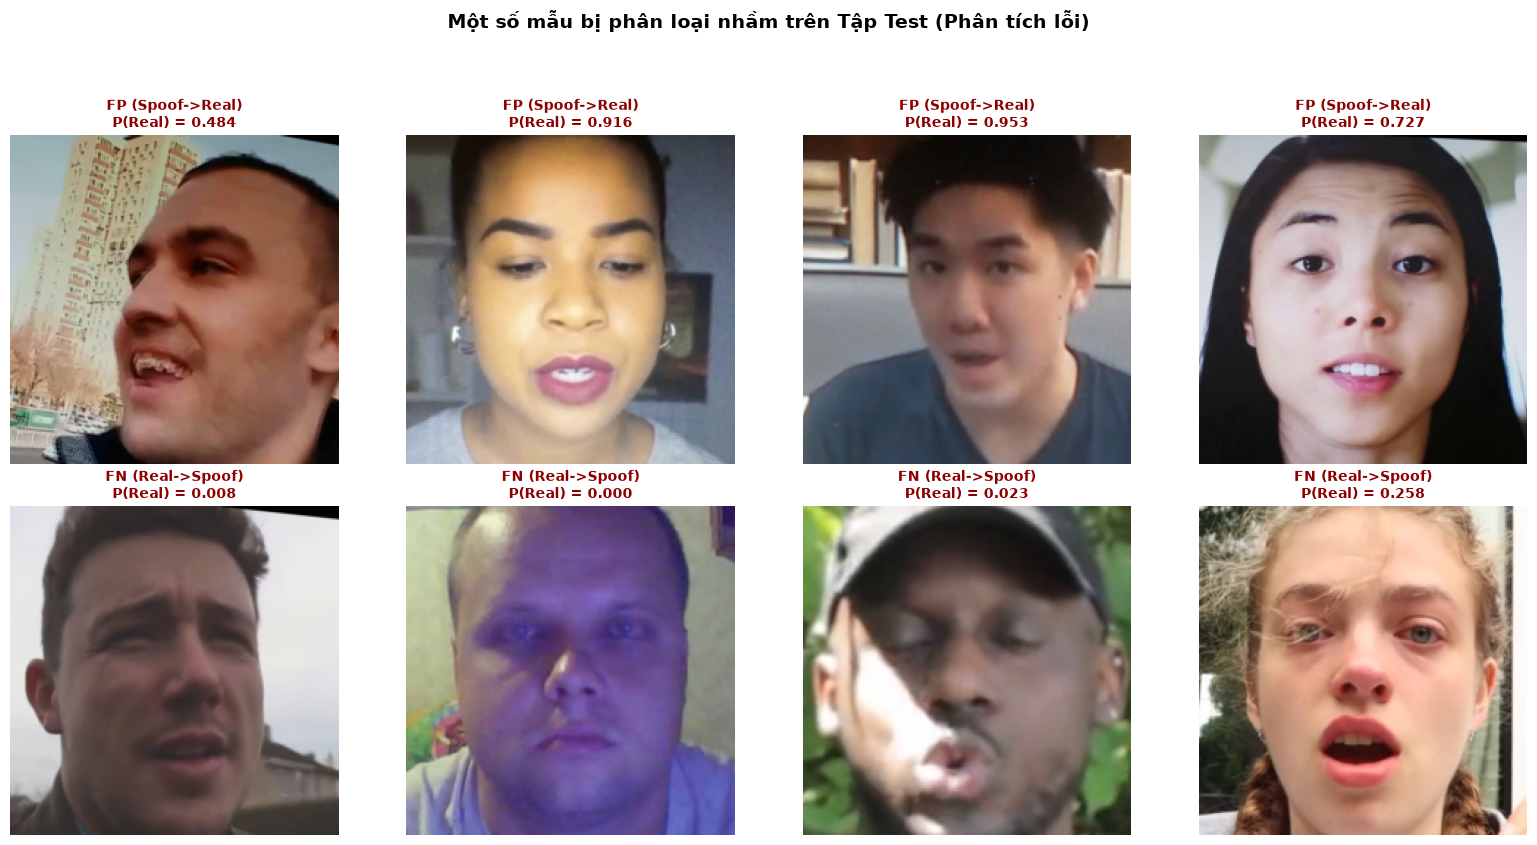

In [5]:
# Thư mục lưu biểu đồ báo cáo
plot_dir = "../output/baseline"

# 1. Vẽ đồ thị Training (Loss & Error Rates)
plot_training_history(history, save_dir=plot_dir)

# 2. Chạy suy diễn trên Test set và vẽ ROC, Confusion Matrix
best_epoch_idx = np.argmin(history['val_acer']) if len(history['val_acer']) > 0 else 0
best_threshold = history['val_eer_threshold'][best_epoch_idx] if len(history['val_eer_threshold']) > 0 else 0.5

test_probs, test_labels, test_preds = evaluate_test_set(
    model, val_loader, test_loader, config.DEVICE, class_names, 
    threshold=best_threshold, save_dir=plot_dir
)

# 3. Phân tích lỗi trực quan (False Positives & False Negatives)
plot_misclassified_samples(
    test_loader.dataset, test_probs, test_preds, test_labels, class_names, 
    num_samples=4, save_dir=plot_dir
)

In [6]:
OUT_MODEL_DIR = "../output/models/baseline"
os.makedirs(OUT_MODEL_DIR, exist_ok=True)
onnx_path = os.path.join(OUT_MODEL_DIR, "baseline_model.onnx")

# Chuyển mô hình về chế độ eval và tạo tensor dummy
model.eval()
dummy_input = torch.randn(1, 3, config.IMG_SIZE, config.IMG_SIZE, device=device)

# Xuất mô hình ra định dạng ONNX để dùng cho Netron
torch.onnx.export(
    model, 
    dummy_input, 
    onnx_path, 
    input_names=['input'], 
    output_names=['output'],
)
print(f"Đã xuất mô hình ONNX thành công tại: {onnx_path}")

[torch.onnx] Obtain model graph for `BaselineModelCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `BaselineModelCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Đã xuất mô hình ONNX thành công tại: ../output/models/baseline/baseline_model.onnx
